# Notebook 2: Chart/Image Modality - Candlestick Pattern Recognition
### Simple comparison between foduucom/stockmarket-pattern-detection-yolov8 vs aungkyawwin/Candlestick_Pattern

1. foduucom/stockmarket-pattern-detection-yolov8: YOLOv8-based object detection model trained on stock chart screenshots; detects macro level chart-level patterns like Head and Shoulders, Triangles, and W-Bottoms

2. aungkyawwin/Candlestick_Pattern: custom ViT-based candlestick classification model; identifies micro level individual candle patterns like doji, hammer, and engulfing patterns with probability/confidence scores

### Step 0 - Basic check that we are in virtual environment

In [4]:
import sys
print(sys.executable)

C:\Users\KJ\Documents\School\FYP\Feature Prototype ENV\.venv\Scripts\python.exe


### Step 1 - Install dependencies and Imports

In [5]:
# Install dependencies
# * my dependencies are already installed directly in venv through terminal so it is commented out
# * ipywidget for simple classic progressbar

# %pip install mplfinance yfinance ultralytics transformers pillow torch ipywidgets==8.1.2 --quiet

In [10]:
# Imports
import os
os.environ["HF_HUB_DISABLE_TELEMETRY"] = "1"
import pandas as pd
import numpy as np
import mplfinance as mpf
import matplotlib.pyplot as plt
from PIL import Image
from transformers import ViTForImageClassification, ViTImageProcessor, pipeline, ViTModel, logging
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from huggingface_hub import hf_hub_download
from ultralytics import YOLO
import warnings
warnings.filterwarnings('ignore')
logging.set_verbosity_error()

### Step 2 - Create mock sample chart from hardcoded OHLC data
- hardcoded to keep this simple and avoid API dependency
- mock OHLC data are intended to simulate a mild downward trend chart
- Volume is excluded as it does not provide meaningful value towards our goal

In [7]:
np.random.seed(1)
dates = pd.date_range(end='2026-05-01', periods=60, freq='D') # 60 daily dates ending on 2026 may

# Build a realistic price walk
close = [1.0900]
for _ in range(59):
    change = np.random.normal(-0.0005, 0.0030) # slightly downwards drift with negative mean and slight std dev
    close.append(round(close[-1] + change, 5))

# Vary the open,high,low,close prices
close = np.array(close)
high = close + np.abs(np.random.normal(0.0015, 0.0010, 60))
low = close - np.abs(np.random.normal(0.0015, 0.0010, 60))
open_ = close - np.random.normal(0.0002, 0.0015, 60) # added '_' as 'open' itself is already a python built-in func

df = pd.DataFrame({
    'Open': np.round(open_, 5),
    'High': np.round(high, 5),
    'Low': np.round(low, 5),
    'Close': np.round(close, 5)
}, index=dates)

df.index.name = 'Date'

print("OHLC sample (first 5 rows):")
print(df.head())

OHLC sample (first 5 rows):
               Open     High      Low    Close
Date                                          
2026-03-03  1.09028  1.09239  1.08809  1.09000
2026-03-04  1.09608  1.09512  1.09289  1.09437
2026-03-05  1.09136  1.09478  1.09131  1.09203
2026-03-06  1.08900  1.09196  1.08718  1.08995
2026-03-07  1.08409  1.08743  1.08276  1.08623


### Step 3 - Generate chart image

Index(['Open', 'High', 'Low', 'Close'], dtype='str')
Chart saved to: sample_chart.png


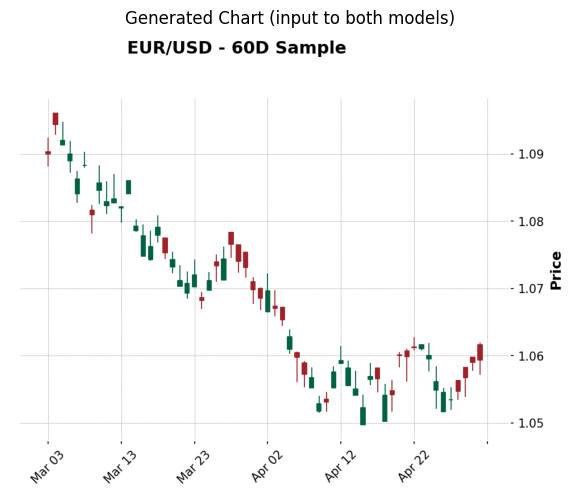

In [8]:
chart_path = "sample_chart.png"

print(df.columns)
# Use mpf library for plotting
mpf.plot(
    df,
    type='candle',
    style='charles',
    title='EUR/USD - 60D Sample',
    ylabel='Price',
    volume=False, # volume not needed
    savefig=dict(fname=chart_path, dpi=150, bbox_inches='tight')
)

print(f"Chart saved to: {chart_path}")

# Show inline
img = Image.open(chart_path)
plt.figure(figsize=(12, 6))
plt.imshow(img)
plt.axis('off')
plt.title("Generated Chart (input to both models)")
plt.show()

### Step 4 - Test aungkyawwin/Candlestick_Pattern model
- manual load weights from .pt
- we will replicate Space 'app.py' loading approach since model is a custom ViT with a custom classification head, not a standard HuggingFace model
- reference implementation from developer: https://huggingface.co/spaces/aungkyawwin/Candlestick_Pattern/blob/main/app.py

In [11]:
class CandlestickModel(nn.Module):
    def __init__(self, model_name, num_classes):
        super().__init__()
        self.base_model = ViTModel.from_pretrained(model_name)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Linear(self.base_model.config.hidden_size, num_classes)

    def forward(self, x):
        x = self.base_model(x).last_hidden_state
        x = self.pool(x.permute(0, 2, 1)).squeeze(-1)
        return torch.sigmoid(self.classifier(x))

device = "cuda" if torch.cuda.is_available() else "cpu" # option for nvidia gpu if present

print("Downloading candlestick-pattern-detector.pt from HuggingFace...")
model_path = hf_hub_download(repo_id="aungkyawwin/Candlestick_Pattern", filename="candlestick-pattern-detector.pt")

print("Loading CandlestickModel...")
candle_model = CandlestickModel("google/vit-base-patch16-224", num_classes=7).to(device)
candle_model.load_state_dict(torch.load(model_path, map_location=device))
candle_model.eval()

CANDLE_LABELS = ['doji', 'bullish_engulfing', 'bearish_engulfing', 'hammer', 'morning_star', 'shooting_star', 'none']

transform = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor()]) # resize to 224x224 where VIT expects, and scale img pixel value 0-255 to 0-1 for tensor

print("Model loaded. Running inference...")
img_pil = Image.open(chart_path).convert("RGB") # load img and convert to rgb
input_tensor = transform(img_pil).unsqueeze(0).to(device) # prep for model inference (resize+convert tensor); unsqueeze to add extra dimension to fit shape model want

with torch.no_grad():
    output = candle_model(input_tensor)

probs = output.squeeze().cpu().numpy()
# Ranked list of prediction
results_candle = sorted(
    [{"label": CANDLE_LABELS[i], "score": float(probs[i])} for i in range(len(CANDLE_LABELS))],
    key=lambda x: x['score'], reverse=True
)

print("\n--- Candlestick_Pattern Results ---")
for r in results_candle:
    print(f" {r['label']:<25} {r['score']*100:.1f}%")

top_candle = results_candle[0]
print(f"\nTop prediction: {top_candle['label']} ({top_candle['score']*100:.1f}% confidence)")

Loading CandlestickModel...


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

Model loaded. Running inference...

--- Candlestick_Pattern Results ---
 doji                      95.2%
 shooting_star             44.6%
 hammer                    10.9%
 bullish_engulfing         10.0%
 morning_star              7.9%
 bearish_engulfing         6.5%
 none                      2.7%

Top prediction: doji (95.2% confidence)


### Step 5 - Test foduucom/stockmarket-pattern-detection-yolov8
- manual loaded same as previous model
- we will not be using it's screenshot feature as we are reconstructing chart from scratch using mpl library
- referenced from final section of documentation: https://huggingface.co/foduucom/stockmarket-pattern-detection-yolov8 and https://github.com/foduucom/Stockmarket-pattern-detection

In [12]:
# Supported labels class from documentation
PATTERN_CLASSES = ['Head and shoulders bottom', 'Head and shoulders top', 'M_Head', 'StockLine', 'Triangle', 'W_Bottom']

print("Loading YOLO model...")
model_path = hf_hub_download(repo_id="foduucom/stockmarket-pattern-detection-yolov8", filename="model.pt")
yolo_model = YOLO(model_path)

results_yolo = yolo_model(chart_path, verbose=False)

print("YOLO Pattern Detection Results:")
boxes = results_yolo[0].boxes
if boxes and len(boxes) > 0:
    for box in boxes:
        cls_idx = int(box.cls.item())
        conf = box.conf.item()
        label = PATTERN_CLASSES[cls_idx] if cls_idx < len(PATTERN_CLASSES) else f"class_{cls_idx}"
        print(f" Detected: {label:<35} Confidence: {conf*100:.1f}%")

    top_yolo_idx = int(boxes[0].cls.item())
    top_yolo_label = PATTERN_CLASSES[top_yolo_idx] if top_yolo_idx < len(PATTERN_CLASSES) else "unknown"
    top_yolo_conf = boxes[0].conf.item()
else:
    print(" No patterns detected.")
    top_yolo_label = "none"
    top_yolo_conf = 0.0

Loading YOLO model...
YOLO Pattern Detection Results:
 Detected: Head and shoulders bottom           Confidence: 61.9%


### Step 6 - Visualize both model outputs
1. Model A (aungkyawwin/Candlestick_Pattern) outputs a list of dict storing candlestick pattern label and predicted confidence
   - Bar chart perfect to visualize
2. Model B (foduucom/stockmarket-pattern-detection-yolov8) outputs a list of detected chart patterns containing the pattern label, confidence score, and bounding box coordinates
   - Bounding box coordinates allow us to see the overlay directly on our chart

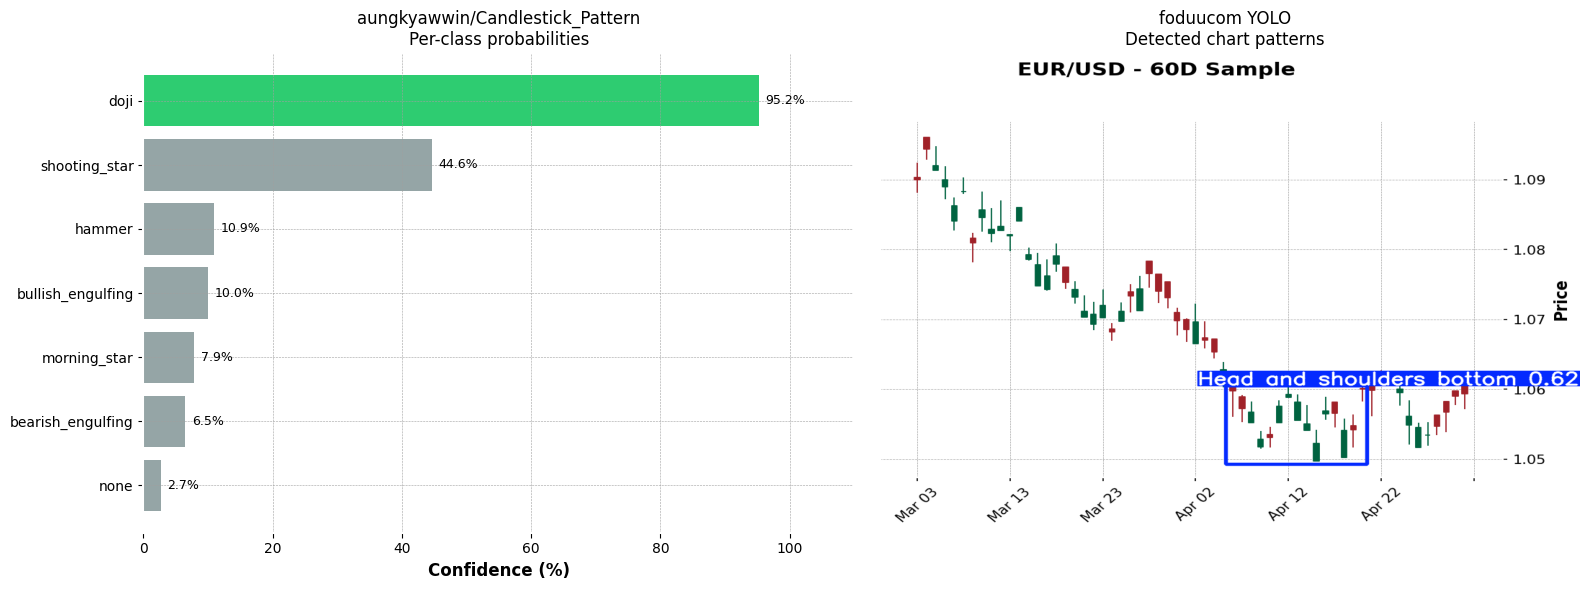

Comparison figure saved.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Candlestick model bar chart
labels = [r['label'] for r in results_candle]
scores = [r['score'] * 100 for r in results_candle]
colors = ['#2ecc71' if s == max(scores) else '#95a5a6' for s in scores]

axes[0].barh(labels[::-1], scores[::-1], color=colors[::-1])
axes[0].set_xlabel("Confidence (%)")
axes[0].set_title("aungkyawwin/Candlestick_Pattern\nPer-class probabilities")
axes[0].set_xlim(0, 110)
for i, (s, l) in enumerate(zip(scores[::-1], labels[::-1])):
    axes[0].text(s + 1, i, f"{s:.1f}%", va='center', fontsize=9)

# Right: YOLO annotated chart
annotated = results_yolo[0].plot()
axes[1].imshow(annotated[..., ::-1])
axes[1].set_aspect('auto')
axes[1].axis('off')
axes[1].set_title("foduucom YOLO\nDetected chart patterns")

plt.tight_layout()
plt.savefig("chart_modality_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Comparison figure saved.")

### Step 7 - Map outputs to directional signal for fusion
- for display purpose only, to show what input source the fusion system would receive
- model is treated as a black-box signal generator
- we will be selecting 1 for final use, both are only shown for comparison sake

In [15]:
# Candlestick patterns -> directional bias
CANDLE_SIGNAL_MAP = {
    'doji': 0, # indecision
    'hammer': 1, # bullish reversal
    'shooting_star': -1, # bearish reversal
    'morning_star': 1,
    'evening_star': -1,
    'bullish_engulfing': 1,
    'bearish_engulfing': -1,
    'none': 0
}

# Chart patterns -> directional bias
CHART_SIGNAL_MAP = {
    'Head and shoulders top': -1, # bearish
    'Head and shoulders bottom': 1, # bullish
    'M_Head': -1, # bearish (double top)
    'W_Bottom': 1, # bullish (double bottom)
    'Triangle': 0, # neutral (direction unclear)
    'StockLine': 0,
    'none': 0
}

candle_label = top_candle['label'].lower()
candle_conf = top_candle['score']
candle_signal = CANDLE_SIGNAL_MAP.get(candle_label, 0)
chart_signal = CHART_SIGNAL_MAP.get(top_yolo_label, 0)

print("Fusion Input signals")
print(f" Candlestick model : {candle_label:<25} signal={candle_signal:+d}  conf={candle_conf*100:.1f}%")
print(f" YOLO chart model : {top_yolo_label:<25} signal={chart_signal:+d}  conf={top_yolo_conf*100:.1f}%")

Fusion Input signals
 Candlestick model : doji                      signal=+0  conf=95.2%
 YOLO chart model : Head and shoulders bottom signal=+1  conf=61.9%


### Step 7 - Final observation + decision

Observation:
- The candlestick classification model focuses on micro-level candle formations such as doji, hammer, and engulfing patterns
- The YOLO chart detection model focuses on higher-level chart structures such as Head and Shoulders, Triangles, and W-Bottoms
- Both models produced *plausible* outputs on the mock chart sample
- The candlestick model predicted a doji pattern, which generally represents market indecision or weak directional bias
- The YOLO model detected a Head and Shoulders Bottom pattern, indicating a possible bullish reversal structure within the broader chart context

Chosen model for pipeline and reasoning: **foduucom/stockmarket-pattern-detection-yolov8**
- Both models are capable of extracting useful visual trading signals from candlestick charts
- However, the YOLO-based chart detector captures broader structural patterns across the chart instead of focusing only on individual candles
- This provides more contextual information for downstream multimodal fusion and reduces reliance on isolated candle-level signals that may represent short-term noise
- The object detection output also includes bounding box localization, making the prediction easier to visualize and interpret during analysis